# HealthBot - Patient Education Chatbot

This notebook builds a LangGraph workflow for a patient education chatbot. The bot lets a patient pick a health topic, searches for info using Tavily, summarizes it, and then quizzes the patient to check their understanding.

## Setup - Loading API Keys

In [22]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install",
    "python-dotenv", "langgraph", "langchain", "langchain-openai",
    "langchain-community", "tavily-python"], stdout=subprocess.DEVNULL)
print("packages installed")

packages installed


In [23]:
from dotenv import load_dotenv
import os

load_dotenv('config.env')

assert os.getenv('OPENAI_API_KEY') is not None, "Missing OPENAI_API_KEY in config.env"
assert os.getenv('TAVILY_API_KEY') is not None, "Missing TAVILY_API_KEY in config.env"

print("API keys loaded")

API keys loaded


## Imports

In [24]:
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage, ToolMessage, RemoveMessage
import json

## Initialize the LLM and Tavily tool

Using gpt-4o-mini since it's cheaper and works fine for this use case. Tavily is set to return 5 results max.

In [25]:
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

tavily_tool = TavilySearchResults(max_results=5)

llm_with_tools = llm.bind_tools([tavily_tool])

print(f"Using model: {llm.model_name}")
print(f"Search tool: {tavily_tool.name}")

Using model: gpt-4o-mini
Search tool: tavily_search_results_json


## Define the State

The state holds everything that gets passed between nodes - the conversation messages, the topic, search results, summary, quiz data, etc.

In [26]:
class HealthBotState(TypedDict):
    messages: Annotated[list, add_messages]
    health_topic: str
    search_results: str
    summary: str
    quiz_question: str
    user_answer: str
    grade: str
    continue_session: bool

## Define the Workflow Nodes

Each node does one thing - get input, search, summarize, quiz, grade, etc.

### Get the health topic from the patient

In [27]:
def get_health_topic(state: HealthBotState) -> HealthBotState:
    """Asks the patient what they want to learn about."""
    print("\n" + "=" * 50)
    print("  Welcome to HealthBot!")
    print("  Your AI Health Education Assistant")
    print("=" * 50)

    topic = input("What health topic or medical condition would you like to learn about? ")
    print(f"\nSearching for information about: {topic}")

    return {
        "health_topic": topic,
        "messages": [HumanMessage(content=f"I want to learn about {topic}")]
    }

### Search Tavily for medical info

This node uses the LLM with bound tools to trigger a Tavily search. The LLM decides the search query and we execute the tool call, then feed the results back as a ToolMessage.

In [28]:
def search_tavily(state: HealthBotState) -> HealthBotState:
    """Uses the LLM to call Tavily search and get medical info."""
    topic = state["health_topic"]

    search_msg = (
        f"Search for reliable medical information about: {topic}. "
        f"Focus on reputable sources like Mayo Clinic, WebMD, CDC, NIH, and WHO."
    )

    msgs = state["messages"] + [
        SystemMessage(content="You are a medical research assistant. Use the Tavily search tool to find reliable medical information."),
        HumanMessage(content=search_msg)
    ]

    response = llm_with_tools.invoke(msgs)

    new_messages = [response]
    raw_results = ""

    if response.tool_calls:
        for tc in response.tool_calls:
            result = tavily_tool.invoke(tc["args"])
            result_str = json.dumps(result, indent=2)
            raw_results += result_str
            new_messages.append(
                ToolMessage(content=result_str, tool_call_id=tc["id"])
            )

    print("Search complete! Processing results...")

    return {
        "search_results": raw_results,
        "messages": new_messages
    }

### Summarize the search results

The prompt tells the model to only use the search results (no outside knowledge) and to write 3-4 paragraphs in simple language.

In [29]:
def summarize_results(state: HealthBotState) -> HealthBotState:
    """Summarizes search results into patient-friendly language."""
    topic = state["health_topic"]
    search_results = state["search_results"]

    prompt = (
        f"Using ONLY the search results below about '{topic}', write a patient-friendly summary. "
        f"Do not use any outside knowledge beyond what's in these results.\n\n"
        f"Guidelines:\n"
        f"- Write 3-4 paragraphs\n"
        f"- Use simple language a patient can understand\n"
        f"- If you use a medical term, briefly explain it in parentheses\n"
        f"- Cover what the condition is, symptoms, treatments, and prevention\n"
        f"- Keep it helpful and empowering\n\n"
        f"Search Results:\n{search_results}"
    )

    msgs = state["messages"] + [HumanMessage(content=prompt)]
    response = llm.invoke(msgs)

    return {
        "summary": response.content,
        "messages": [response]
    }

### Display summary to the patient

In [30]:
def present_summary(state: HealthBotState) -> HealthBotState:
    """Shows the summary to the patient."""
    print("\n" + "-" * 50)
    print(f"  Health Info: {state['health_topic']}")
    print("-" * 50)
    print(state["summary"])
    print("-" * 50)
    return {}

### Wait for patient to be ready for the quiz

In [31]:
def ready_for_quiz(state: HealthBotState) -> HealthBotState:
    """Waits for the patient to say they're ready."""
    input("\nTake your time reading the summary above. Press Enter when you're ready for a quiz... ")
    print("Preparing your quiz question...")
    return {}

### Generate a quiz question from the summary

In [32]:
def generate_quiz(state: HealthBotState) -> HealthBotState:
    """Creates one quiz question based only on the summary."""
    summary = state["summary"]

    prompt = (
        f"Based ONLY on this summary, create exactly ONE quiz question for the patient. "
        f"Don't use any outside knowledge.\n\n"
        f"The question should:\n"
        f"- Be answerable from the summary alone\n"
        f"- Test a key concept\n"
        f"- Be clear and straightforward\n"
        f"- Just output the question, nothing else\n\n"
        f"Summary:\n{summary}"
    )

    msgs = state["messages"] + [HumanMessage(content=prompt)]
    response = llm.invoke(msgs)

    return {
        "quiz_question": response.content,
        "messages": [response]
    }

### Show the quiz question and get the patient's answer

In [ ]:
def present_quiz(state: HealthBotState) -> HealthBotState:
    """Displays the quiz question and collects the patient's answer."""
    import sys

    print("\n" + "-" * 50)
    print("  Comprehension Check")
    print("-" * 50)
    print(f"\n{state['quiz_question']}\n")
    sys.stdout.flush()  # make sure the question renders before input() blocks

    answer = input("Your answer: ")

    return {
        "user_answer": answer,
        "messages": [HumanMessage(content=f"My answer to the quiz question is: {answer}")]
    }

### Grade the patient's answer

The grading prompt tells the model to use only the summary as its source, give a letter grade (A-F), and cite specific parts of the summary in its feedback.

In [35]:
def grade_answer(state: HealthBotState) -> HealthBotState:
    """Grades the patient's quiz answer with a letter grade and feedback."""
    summary = state["summary"]
    question = state["quiz_question"]
    answer = state["user_answer"]

    prompt = (
        f"Grade this patient's answer to a health quiz question. "
        f"Use ONLY the summary below as your source.\n\n"
        f"Summary:\n{summary}\n\n"
        f"Question:\n{question}\n\n"
        f"Patient's Answer:\n{answer}\n\n"
        f"Give a letter grade (A, B, C, D, or F):\n"
        f"- A = excellent, accurate and thorough\n"
        f"- B = good, mostly correct with minor gaps\n"
        f"- C = fair, some knowledge but notable gaps\n"
        f"- D = poor, significant inaccuracies\n"
        f"- F = incorrect or no understanding shown\n\n"
        f"Provide justification for the grade and cite specific parts "
        f"of the summary to help the patient learn.\n\n"
        f"Format:\nGrade: [letter]\n\nFeedback: [explanation with citations]"
    )

    msgs = state["messages"] + [HumanMessage(content=prompt)]
    response = llm.invoke(msgs)

    return {
        "grade": response.content,
        "messages": [response]
    }

### Show the grade

In [36]:
def present_grade(state: HealthBotState) -> HealthBotState:
    """Shows the grade and feedback."""
    print("\n" + "-" * 50)
    print("  Quiz Results")
    print("-" * 50)
    print(state["grade"])
    print("-" * 50)
    return {}

### Ask if they want to continue or exit

In [37]:
def ask_continue(state: HealthBotState) -> HealthBotState:
    """Asks patient if they want another topic or to exit."""
    choice = input("\nWould you like to learn about another health topic? (yes/no): ").strip().lower()

    if choice in ["yes", "y"]:
        print("Starting a new session...\n")
        return {"continue_session": True}
    else:
        print("\nThanks for using HealthBot! Stay healthy!")
        return {"continue_session": False}

### Reset state for a new topic

Clears out all the old data so previous health info doesn't leak into the next session.

In [38]:
def reset_state(state: HealthBotState) -> HealthBotState:
    """Wipes the state clean for a new topic."""
    return {
        "health_topic": "",
        "search_results": "",
        "summary": "",
        "quiz_question": "",
        "user_answer": "",
        "grade": "",
        "continue_session": False,
        "messages": [RemoveMessage(id=m.id) for m in state["messages"]]
    }

## Conditional edge - continue or exit

In [39]:
def should_continue(state: HealthBotState) -> str:
    """Routes to reset_state if continuing, or END if done."""
    if state.get("continue_session", False):
        return "reset_state"
    return END

## Build and compile the LangGraph workflow

In [40]:
workflow = StateGraph(HealthBotState)

workflow.add_node("get_health_topic", get_health_topic)
workflow.add_node("search_tavily", search_tavily)
workflow.add_node("summarize_results", summarize_results)
workflow.add_node("present_summary", present_summary)
workflow.add_node("ready_for_quiz", ready_for_quiz)
workflow.add_node("generate_quiz", generate_quiz)
workflow.add_node("present_quiz", present_quiz)
workflow.add_node("grade_answer", grade_answer)
workflow.add_node("present_grade", present_grade)
workflow.add_node("ask_continue", ask_continue)
workflow.add_node("reset_state", reset_state)

workflow.add_edge(START, "get_health_topic")
workflow.add_edge("get_health_topic", "search_tavily")
workflow.add_edge("search_tavily", "summarize_results")
workflow.add_edge("summarize_results", "present_summary")
workflow.add_edge("present_summary", "ready_for_quiz")
workflow.add_edge("ready_for_quiz", "generate_quiz")
workflow.add_edge("generate_quiz", "present_quiz")
workflow.add_edge("present_quiz", "grade_answer")
workflow.add_edge("grade_answer", "present_grade")
workflow.add_edge("present_grade", "ask_continue")

workflow.add_conditional_edges(
    "ask_continue",
    should_continue,
    {"reset_state": "reset_state", END: END}
)
workflow.add_edge("reset_state", "get_health_topic")

graph = workflow.compile()
print("Workflow compiled!")
print(f"Nodes: {list(graph.nodes.keys())}")

Workflow compiled!
Nodes: ['__start__', 'get_health_topic', 'search_tavily', 'summarize_results', 'present_summary', 'ready_for_quiz', 'generate_quiz', 'present_quiz', 'grade_answer', 'present_grade', 'ask_continue', 'reset_state']


## Visualize the workflow

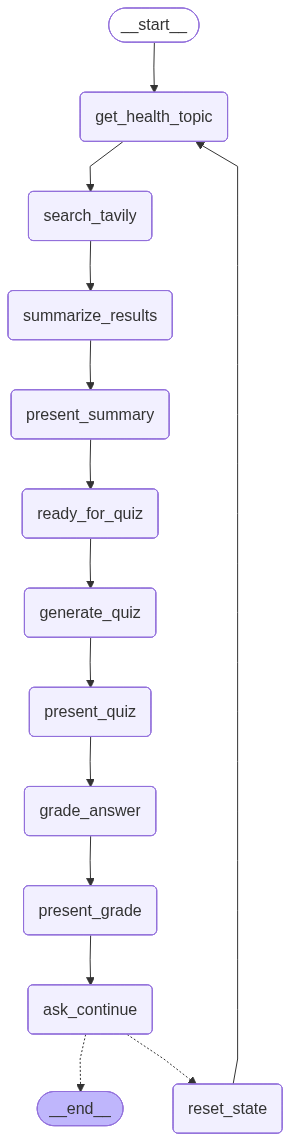

In [41]:
try:
    from IPython.display import Image, display
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print("Workflow flow:")
    print("START -> get_health_topic -> search_tavily -> summarize_results")
    print("-> present_summary -> ready_for_quiz -> generate_quiz -> present_quiz")
    print("-> grade_answer -> present_grade -> ask_continue")
    print("-> [reset_state -> get_health_topic] OR [END]")

## Run HealthBot

In [42]:
initial_state = {
    "messages": [],
    "health_topic": "",
    "search_results": "",
    "summary": "",
    "quiz_question": "",
    "user_answer": "",
    "grade": "",
    "continue_session": False
}

result = graph.invoke(initial_state, {"recursion_limit": 100})


  Welcome to HealthBot!
  Your AI Health Education Assistant

Searching for information about: cancer
Search complete! Processing results...

--------------------------------------------------
  Health Info: cancer
--------------------------------------------------
Cancer is a disease that happens when the body's cells grow out of control. Normally, our cells grow, divide, and die in a controlled way. However, cancer cells do not follow these rules. They can form lumps called tumors, which can be either benign (not cancerous) or malignant (cancerous). Malignant tumors can spread to other parts of the body, making cancer a serious condition that needs attention.

Symptoms of cancer can vary widely depending on the type and location of the cancer. Some common signs include unexplained weight loss, fatigue (feeling very tired), pain, changes in skin, or unusual bleeding. It's important to pay attention to your body and talk to a doctor if you notice any changes that concern you. Early de